In [1]:
import os
import numpy as np
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import itertools

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.1


In [2]:
# ==========================================
# 1. Dataset loader (train / val / test)
# ==========================================

class HydroTFDataset(tf.keras.utils.Sequence):
    """
    Assumes:
      root/
        class0/*.png, class1/*.png, ...
    You will create three instances for train/val/test.
    """
    def __init__(self, root_dir, class_to_idx=None, batch_size=32, shuffle=True, target_size=(224, 224)):
        self.root_dir = root_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.target_size = target_size

        self.samples = []
        self.class_to_idx = class_to_idx if class_to_idx is not None else {}
        classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

        if class_to_idx is None:
            for idx, cls in enumerate(classes):
                self.class_to_idx[cls] = idx

        for cls in classes:
            cls_idx = self.class_to_idx[cls]
            cls_path = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_path):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".bmp")):
                    self.samples.append((os.path.join(cls_path, fname), cls_idx))

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.samples))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_paths_labels = [self.samples[i] for i in batch_indices]

        batch_imgs = []
        batch_labels = []

        for path, label in batch_paths_labels:
            img = Image.open(path).convert("RGB")
            img = img.resize(self.target_size)
            img = np.array(img).astype("float32")
            # ResNet50 preprocessing (RGB -> BGR, mean subtraction, etc.) [web:33][web:46]
            img = preprocess_input(img)
            batch_imgs.append(img)
            batch_labels.append(label)

        batch_imgs = np.stack(batch_imgs, axis=0)
        batch_labels = np.array(batch_labels, dtype="int32")

        return batch_imgs, batch_labels

# paths
train_root = "C:\\Users\\SATARUPA\\OneDrive\\Desktop\\Tiny ML\\Hydrophobicity Classes Photos\\train"
val_root   = "C:\\Users\\SATARUPA\\OneDrive\\Desktop\\Tiny ML\\Hydrophobicity Classes Photos\\validation"
test_root  = "C:\\Users\\SATARUPA\\OneDrive\\Desktop\\Tiny ML\\Hydrophobicity Classes Photos\\test"

batch_size = 32

# Create train dataset first to fix class_to_idx
train_seq = HydroTFDataset(train_root, batch_size=batch_size, shuffle=True)
class_to_idx = train_seq.class_to_idx
num_classes = len(class_to_idx)

# Use same mapping for val/test
val_seq  = HydroTFDataset(val_root,  class_to_idx=class_to_idx, batch_size=batch_size, shuffle=False)
test_seq = HydroTFDataset(test_root, class_to_idx=class_to_idx, batch_size=batch_size, shuffle=False)

print("Classes:", class_to_idx)


Classes: {'HC1': 0, 'HC2': 1, 'HC3': 2, 'HC4': 3, 'HC5': 4, 'HC6': 5, 'HC7': 6}


In [3]:
# ==========================================
# 2. ResNet50 + transfer learning (Keras)
# ==========================================

# Base ResNet50 without top, global average pooling for 2048‑D features [web:33][web:35][web:46]
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg"   # global average pooling -> 2048‑D
)

# Freeze base initially (optional, you can unfreeze later for fine‑tuning)
base_model.trainable = False

# New classification head
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="resnet50_hydrophobicity")

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "resnet50_hydrophobicity"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 7)                 3591      
                                                                 
Total params: 24,640,391
Trainable params: 1,052,679
Non-trainable params: 23,587,712
_________________________________________________________________


In [ ]:
# ==========================================
# 3. Training with train/val
# ==========================================

epochs = 10  # adjust

history = model.fit(
    train_seq,
    epochs=epochs,
    validation_data=val_seq
)

# Optional: unfreeze some layers for fine‑tuning
# base_model.trainable = True
# model.compile(optimizer=keras.optimizers.Adam(1e-5),
#               loss="sparse_categorical_crossentropy",
#               metrics=["accuracy"])
# history_ft = model.fit(train_seq, epochs=5, validation_data=val_seq)

# Save full model as .keras (Keras native format) [web:48][web:50][web:53]
model.save("teacher_model_resnet50.keras")

Epoch 1/10
88/88 [==============================] - 101s 878ms/step - loss: 1.0122 - accuracy: 0.6268 - val_loss: 0.2967 - val_accuracy: 0.9314
Epoch 2/10
88/88 [==============================] - 25s 286ms/step - loss: 0.3519 - accuracy: 0.8818 - val_loss: 0.1780 - val_accuracy: 0.9614
Epoch 3/10
88/88 [==============================] - 24s 269ms/step - loss: 0.2424 - accuracy: 0.9207 - val_loss: 0.1418 - val_accuracy: 0.9586
Epoch 4/10
88/88 [==============================] - 27s 309ms/step - loss: 0.1894 - accuracy: 0.9414 - val_loss: 0.1133 - val_accuracy: 0.9743
Epoch 5/10
88/88 [==============================] - 27s 304ms/step - loss: 0.1494 - accuracy: 0.9514 - val_loss: 0.1014 - val_accuracy: 0.9771
Epoch 6/10
88/88 [==============================] - 25s 277ms/step - loss: 0.1324 - accuracy: 0.9600 - val_loss: 0.0986 - val_accuracy: 0.9686
Epoch 7/10
88/88 [==============================] - 24s 276ms/step - loss: 0.1251 - accuracy: 0.9593 - val_loss: 0.0875 - val_accuracy: 0.981

In [5]:
# ==========================================
# 4. Embedding model (penultimate layer)
# ==========================================

# We want the 2048‑D embedding before the Dense(512) head.
# Our base_model already outputs the global average pooled features.
# find the penultimate layer by name or index
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.output_shape)

# suppose the Dense(512) layer is named "dense" (check your summary)
penultimate_layer = model.get_layer("dense")  # or by index: model.layers[-2]

embedding_model = keras.Model(
    inputs=model.input,
    outputs=penultimate_layer.output,
    name="hydrophobicity_embedding_model"
)

embedding_model.summary()

def get_embeddings(sequence, embed_model):
    all_embeds = []
    all_labels = []
    for batch_imgs, batch_labels in sequence:
        feats = embed_model.predict(batch_imgs, verbose=0)  # [N, 512]
        all_embeds.append(feats)
        all_labels.append(batch_labels)
    X = np.concatenate(all_embeds, axis=0)
    y = np.concatenate(all_labels, axis=0)
    return X, y

X_train, y_train = get_embeddings(train_seq, embedding_model)
X_val,   y_val   = get_embeddings(val_seq,   embedding_model)
X_test,  y_test  = get_embeddings(test_seq,  embedding_model)

print("Train embeddings:", X_train.shape)
print("Val embeddings  :", X_val.shape)
print("Test embeddings :", X_test.shape)



0 input_2 [(None, 224, 224, 3)]
1 resnet50 (None, 2048)
2 dense (None, 512)
3 dropout (None, 512)
4 dense_1 (None, 7)
Model: "hydrophobicity_embedding_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
Total params: 24,636,800
Trainable params: 1,049,088
Non-trainable params: 23,587,712
_________________________________________________________________
Train embeddings: (2800, 512)
Val embeddings  : (700, 512)
Test embeddings : (1036, 512)


In [6]:
# ==========================================
# 5. PCA for stable covariance (optional)
# ==========================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

pca_dim = 50
pca = PCA(n_components=pca_dim, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("PCA train shape:", X_train_pca.shape)

# Choose which space to use for separability analysis:
Z_train, Z_val, Z_test = X_train_pca, X_val_pca, X_test_pca
y_tr, y_v, y_te = y_train, y_val, y_test
classes = np.unique(y_tr)

PCA train shape: (2800, 50)


In [7]:
# ==========================================
# 6. Separability metrics
# ==========================================

# 3.1 Intra‑class variance
def intra_class_variance(Z, y):
    var_dict = {}
    for c in np.unique(y):
        Zc = Z[y == c]
        var_dict[int(c)] = Zc.var(axis=0).mean()
    return var_dict

intra_var = intra_class_variance(Z_train, y_tr)
print("\n3.1 Intra‑class variance (train):")
for c, v in intra_var.items():
    print(f"  class {c}: {v:.6f}")


3.1 Intra‑class variance (train):
  class 0: 4.906032
  class 1: 5.059690
  class 2: 4.215422
  class 3: 2.262295
  class 4: 2.531627
  class 5: 2.172612
  class 6: 2.512007


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


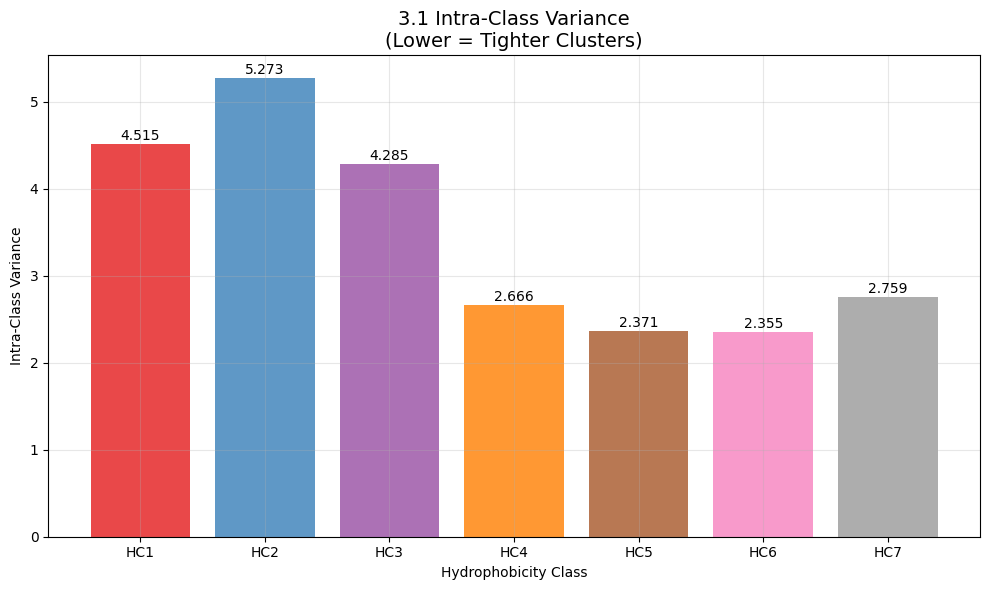

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define class_names from your classes (HC1 to HC7 from your notebook)
class_names = [f"HC{int(c)+1}" for c in classes]  # classes already exists in your notebook

# ==========================================
# 3.1 INTRA-CLASS VARIANCE VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(intra_var)), list(intra_var.values()), 
               color=plt.cm.Set1(np.linspace(0, 1, len(classes))), alpha=0.8)
plt.xlabel('Hydrophobicity Class')
plt.ylabel('Intra-Class Variance')
plt.title('3.1 Intra-Class Variance\n(Lower = Tighter Clusters)', fontsize=14)
plt.xticks(range(len(class_names)), class_names)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, intra_var.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('3_1_intra_class_variance.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
# 3.2 Inter‑class centroid distances
def class_centroids(Z, y):
    mu = {}
    for c in np.unique(y):
        mu[int(c)] = Z[y == c].mean(axis=0)
    return mu

def inter_class_centroid_distances(centroids):
    dists = {}
    for c1, c2 in itertools.combinations(centroids.keys(), 2):
        d = np.linalg.norm(centroids[c1] - centroids[c2])
        dists[(c1, c2)] = d
    return dists

centroids = class_centroids(Z_train, y_tr)
inter_dists = inter_class_centroid_distances(centroids)
print("\n3.2 Inter‑class centroid distances (train):")
for (c1, c2), d in inter_dists.items():
    print(f"  ({c1}, {c2}): {d:.6f}")


3.2 Inter‑class centroid distances (train):
  (0, 1): 18.243504
  (0, 2): 20.811531
  (0, 3): 23.624084
  (0, 4): 24.357931
  (0, 5): 23.889893
  (0, 6): 28.290071
  (1, 2): 14.237791
  (1, 3): 21.935486
  (1, 4): 23.003214
  (1, 5): 24.181808
  (1, 6): 29.188709
  (2, 3): 16.492428
  (2, 4): 19.594696
  (2, 5): 21.757917
  (2, 6): 28.145113
  (3, 4): 13.524476
  (3, 5): 19.341261
  (3, 6): 27.995594
  (4, 5): 11.697828
  (4, 6): 22.923740
  (5, 6): 15.994746


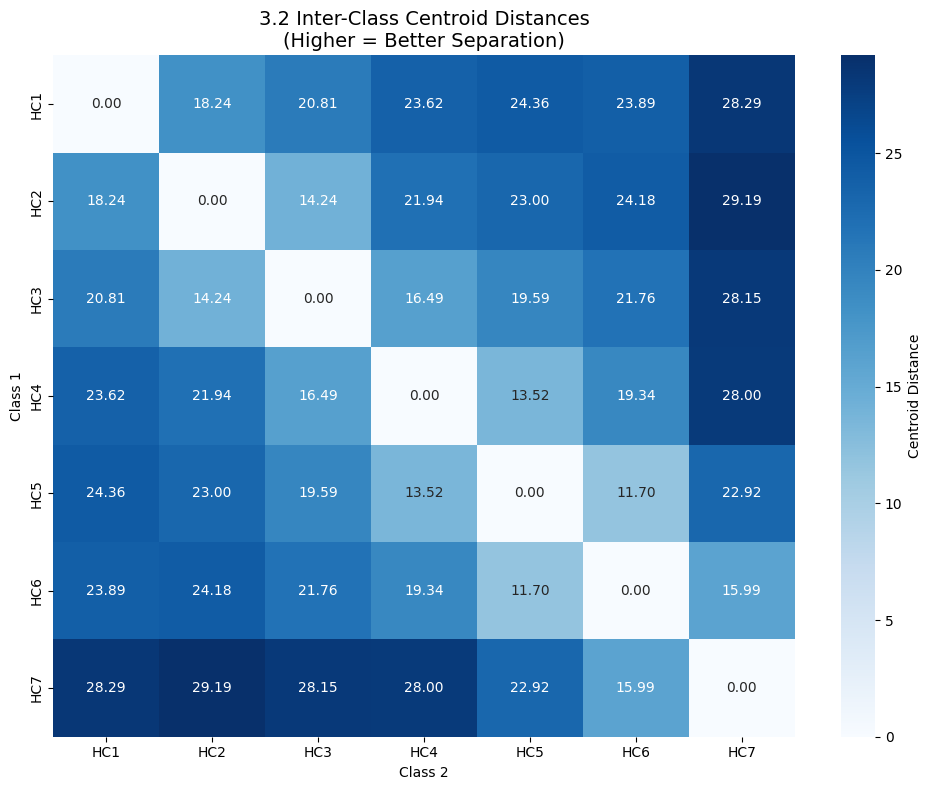

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class_names = [f"HC{int(c)+1}" for c in classes]

# ==========================================
# 3.2 INTER-CLASS CENTROID DISTANCE HEATMAP
# ==========================================
# Recompute if interdists not available (from your existing centroids)
centroids = {}  # if not already computed
for c in classes:
    mask = y_tr == c
    centroids[int(c)] = Z_train[mask].mean(axis=0)

interdists = {}
for c1, c2 in itertools.combinations(sorted(centroids.keys()), 2):
    d = np.linalg.norm(centroids[c1] - centroids[c2])
    interdists[(c1, c2)] = d

# Build symmetric matrix
inter_dist_matrix = np.zeros((len(classes), len(classes)))
for (c1, c2), d in interdists.items():
    inter_dist_matrix[c1, c2] = d
    inter_dist_matrix[c2, c1] = d

plt.figure(figsize=(10, 8))
sns.heatmap(inter_dist_matrix, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, 
            cbar_kws={'label': 'Centroid Distance'})
plt.title('3.2 Inter-Class Centroid Distances\n(Higher = Better Separation)', fontsize=14)
plt.xlabel('Class 2')
plt.ylabel('Class 1')
plt.tight_layout()
plt.savefig('3_2_inter_class_distances.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
# 3.3 Fisher Discriminant Ratio (multi‑class trace(Sb)/trace(Sw)) [web:21][web:24]
def fisher_discriminant_ratio(Z, y):
    overall_mean = Z.mean(axis=0)
    cls = np.unique(y)
    d = Z.shape[1]
    Sw = np.zeros((d, d))
    Sb = np.zeros((d, d))

    for c in cls:
        Zc = Z[y == c]
        mean_c = Zc.mean(axis=0)
        Zc_centered = Zc - mean_c
        Sw += Zc_centered.T @ Zc_centered
        n_c = Zc.shape[0]
        diff = (mean_c - overall_mean).reshape(-1, 1)
        Sb += n_c * (diff @ diff.T)

    fdr = np.trace(Sb) / (np.trace(Sw) + 1e-12)
    return fdr

fdr_score = fisher_discriminant_ratio(Z_train, y_tr)
print(f"\n3.3 Fisher discriminant ratio (train): {fdr_score:.6f}")



3.3 Fisher discriminant ratio (train): 1.217541


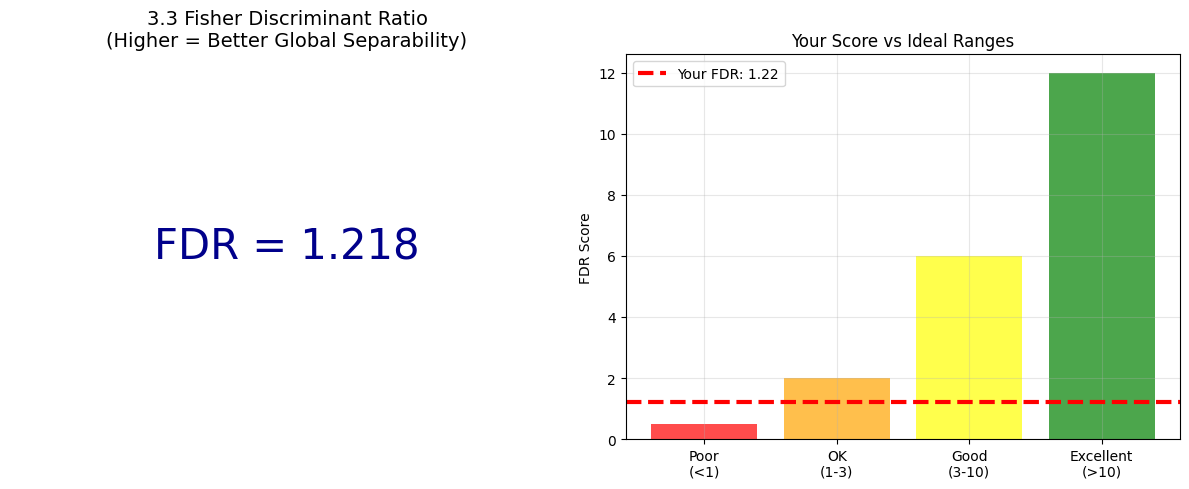

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Big number
ax1.text(0.5, 0.5, f'FDR = {fdr_score:.3f}', fontsize=30, ha='center', va='center',
         transform=ax1.transAxes, color='darkblue')
ax1.set_title('3.3 Fisher Discriminant Ratio\n(Higher = Better Global Separability)', fontsize=14)
ax1.axis('off')

# Bar for context (compare to ideal range)
categories = ['Poor\n(<1)', 'OK\n(1-3)', 'Good\n(3-10)', 'Excellent\n(>10)']
ideal_scores = [0.5, 2, 6, 12]
colors = ['red', 'orange', 'yellow', 'green']
bars = ax2.bar(categories, ideal_scores, color=colors, alpha=0.7)
ax2.axhline(y=fdr_score, color='red', linestyle='--', linewidth=3, label=f'Your FDR: {fdr_score:.2f}')
ax2.set_ylabel('FDR Score')
ax2.set_title('Your Score vs Ideal Ranges')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('3_3_fdr_score.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# 3.4 Bhattacharyya & Chernoff distances (Gaussian) [web:22][web:25][web:31]
def gaussian_params_per_class(Z, y, reg_eps=1e-5):
    params = {}
    for c in np.unique(y):
        Zc = Z[y == c]
        mu_c = Zc.mean(axis=0)
        Sigma_c = np.cov(Zc, rowvar=False)
        Sigma_c += reg_eps * np.eye(Sigma_c.shape[0])
        params[int(c)] = (mu_c, Sigma_c)
    return params

gauss_params = gaussian_params_per_class(Z_train, y_tr)

def bhattacharyya_distance(mu1, mu2, S1, S2):
    S = 0.5 * (S1 + S2)
    diff = (mu2 - mu1).reshape(-1, 1)
    inv_S = np.linalg.inv(S)
    term1 = 0.125 * float(diff.T @ inv_S @ diff)
    det_S = np.linalg.det(S)
    det_S1 = np.linalg.det(S1)
    det_S2 = np.linalg.det(S2)
    term2 = 0.5 * np.log(det_S / np.sqrt(det_S1 * det_S2))
    return term1 + term2

def bhattacharyya_matrix(params):
    cls = sorted(params.keys())
    n = len(cls)
    B = np.zeros((n, n))
    for i, c1 in enumerate(cls):
        mu1, S1 = params[c1]
        for j, c2 in enumerate(cls):
            if i == j:
                B[i, j] = 0.0
            elif i < j:
                mu2, S2 = params[c2]
                d = bhattacharyya_distance(mu1, mu2, S1, S2)
                B[i, j] = B[j, i] = d
    return cls, B

cls_order_B, B_mat = bhattacharyya_matrix(gauss_params)
print("\n3.4 Bhattacharyya distance matrix (train):")
print("class order:", cls_order_B)
print(B_mat)

# Chernoff distance approximation over α grid [web:23][web:26]
def chernoff_distance(mu1, mu2, S1, S2, alphas=None):
    if alphas is None:
        alphas = np.linspace(0.01, 0.99, 25)
    best = 0.0
    for a in alphas:
        Sa = a * S1 + (1 - a) * S2
        diff = (mu2 - mu1).reshape(-1, 1)
        inv_Sa = np.linalg.inv(Sa)
        term1 = 0.5 * a * (1 - a) * float(diff.T @ inv_Sa @ diff)
        det_Sa = np.linalg.det(Sa)
        det_S1 = np.linalg.det(S1)
        det_S2 = np.linalg.det(S2)
        term2 = 0.5 * np.log(det_Sa / (det_S1**a * det_S2**(1 - a)))
        D_alpha = term1 + term2
        if D_alpha > best:
            best = D_alpha
    return best

def chernoff_matrix(params):
    cls = sorted(params.keys())
    n = len(cls)
    C = np.zeros((n, n))
    for i, c1 in enumerate(cls):
        mu1, S1 = params[c1]
        for j, c2 in enumerate(cls):
            if i == j:
                C[i, j] = 0.0
            elif i < j:
                mu2, S2 = params[c2]
                d = chernoff_distance(mu1, mu2, S1, S2)
                C[i, j] = C[j, i] = d
    return cls, C

cls_order_C, C_mat = chernoff_matrix(gauss_params)
print("\n3.4 Chernoff distance matrix (train):")
print("class order:", cls_order_C)
print(C_mat)


3.4 Bhattacharyya distance matrix (train):
class order: [0, 1, 2, 3, 4, 5, 6]
[[ 0.         26.95998848 28.35721628 44.64111532 57.92792508 68.87643387
  90.89358837]
 [26.95998848  0.         14.32683461 39.04631683 52.10345621 65.91466134
  90.75295319]
 [28.35721628 14.32683461  0.         20.20391507 31.79999528 49.89120287
  79.35437036]
 [44.64111532 39.04631683 20.20391507  0.         12.94266059 23.75278162
  49.10722596]
 [57.92792508 52.10345621 31.79999528 12.94266059  0.         10.04211441
  24.95684609]
 [68.87643387 65.91466134 49.89120287 23.75278162 10.04211441  0.
  14.45306323]
 [90.89358837 90.75295319 79.35437036 49.10722596 24.95684609 14.45306323
   0.        ]]

3.4 Chernoff distance matrix (train):
class order: [0, 1, 2, 3, 4, 5, 6]
[[ 0.         26.95998848 28.39923624 44.80752462 58.16665407 69.39142013
  90.89358837]
 [26.95998848  0.         14.32683461 39.72414616 52.75928814 66.3014954
  91.06872354]
 [28.39923624 14.32683461  0.         20.34168466 31.8

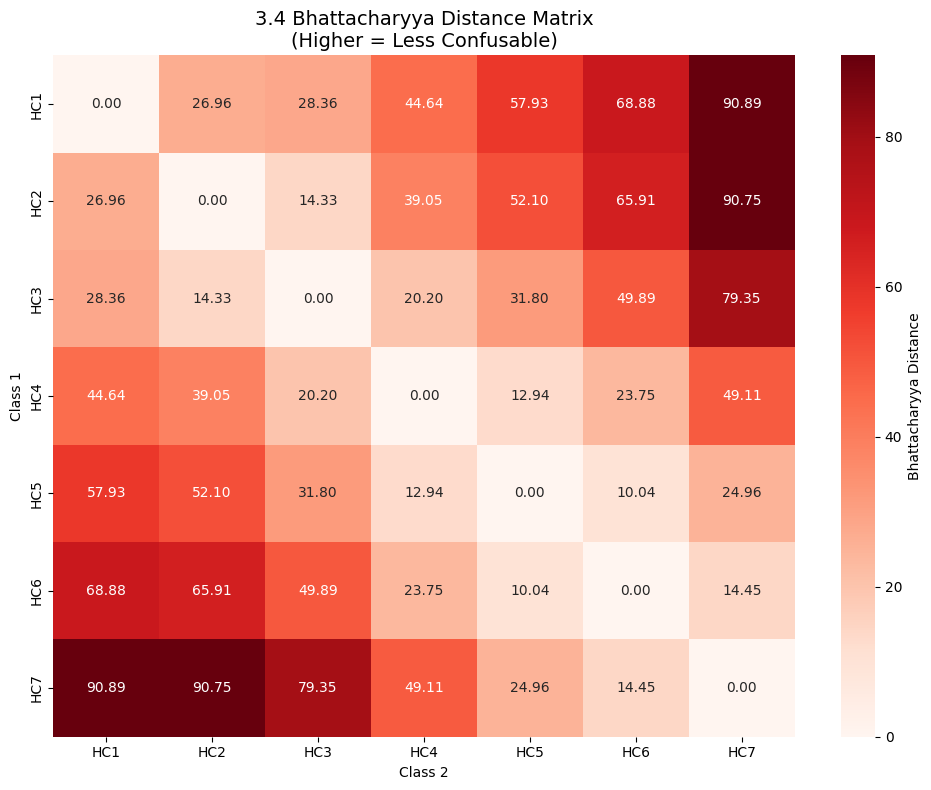

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(B_mat, annot=True, fmt='.2f', cmap='Reds', 
            xticklabels=[f'HC{i+1}' for i in cls_order_B], 
            yticklabels=[f'HC{i+1}' for i in cls_order_B],
            cbar_kws={'label': 'Bhattacharyya Distance'})
plt.title('3.4 Bhattacharyya Distance Matrix\n(Higher = Less Confusable)', fontsize=14)
plt.xlabel('Class 2')
plt.ylabel('Class 1')
plt.tight_layout()
plt.savefig('3_4_bhattacharyya_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

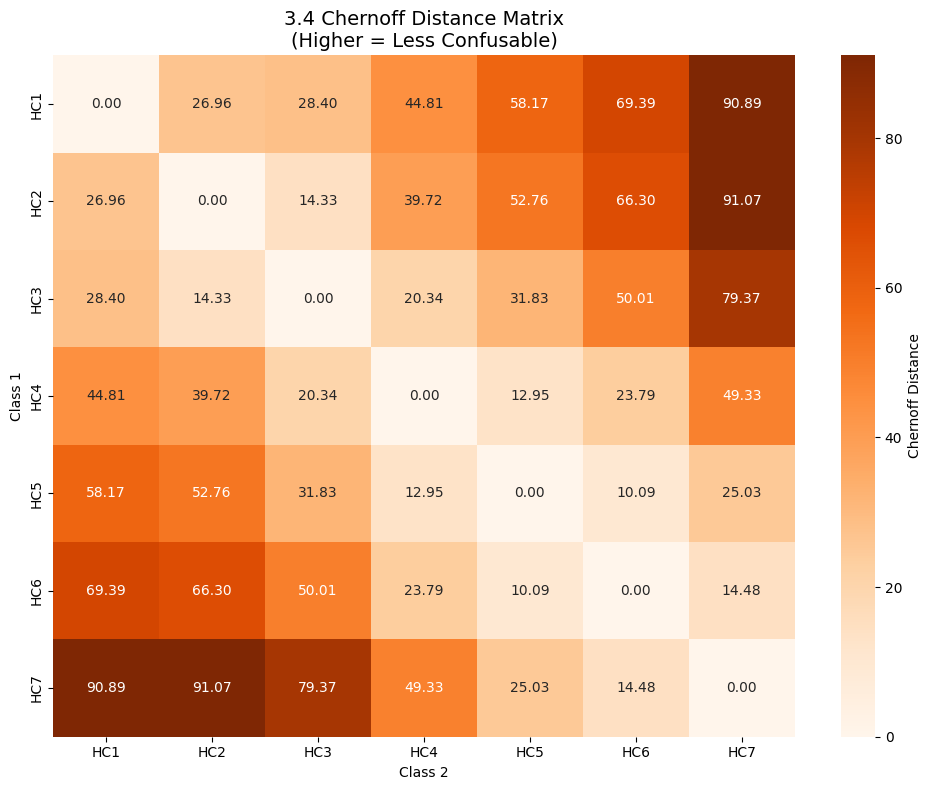

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(C_mat, annot=True, fmt='.2f', cmap='Oranges', 
            xticklabels=[f'HC{i+1}' for i in cls_order_C], 
            yticklabels=[f'HC{i+1}' for i in cls_order_C],
            cbar_kws={'label': 'Chernoff Distance'})
plt.title('3.4 Chernoff Distance Matrix\n(Higher = Less Confusable)', fontsize=14)
plt.xlabel('Class 2')
plt.ylabel('Class 1')
plt.tight_layout()
plt.savefig('3_4_chernoff_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
# 3.5 t‑SNE (UMAP optional) [web:8][web:14]
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
Z_train_tsne = tsne.fit_transform(Z_train)
print("\n3.5 t‑SNE 2D shape:", Z_train_tsne.shape)

# If you want UMAP (pip install umap-learn):
# import umap
# reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42)
# Z_train_umap = reducer.fit_transform(Z_train)
# print("UMAP 2D shape:", Z_train_umap.shape)

# Save everything for later analysis/plots
np.savez(
    "tf_hydrophobicity_embeddings_and_metrics.npz",
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    X_train_pca=X_train_pca,
    X_val_pca=X_val_pca,
    X_test_pca=X_test_pca,
    intra_var=np.array([intra_var[c] for c in classes]),
    B_mat=B_mat,
    C_mat=C_mat,
    cls_order_B=np.array(cls_order_B),
    cls_order_C=np.array(cls_order_C),
    Z_train_tsne=Z_train_tsne
)


3.5 t‑SNE 2D shape: (2800, 2)


NameError: name 'B_mat' is not defined

t-SNE shape: (2800, 2)
Classes: ['Class_1', 'Class_2', 'Class_3', 'Class_4', 'Class_5', 'Class_6', 'Class_7']


C:\Users\SATARUPA\AppData\Local\Temp\ipykernel_24036\2060158501.py:43: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 7
  plt.legend(handles=handles[1:], labels=class_names, title="Hydrophobicity Class")


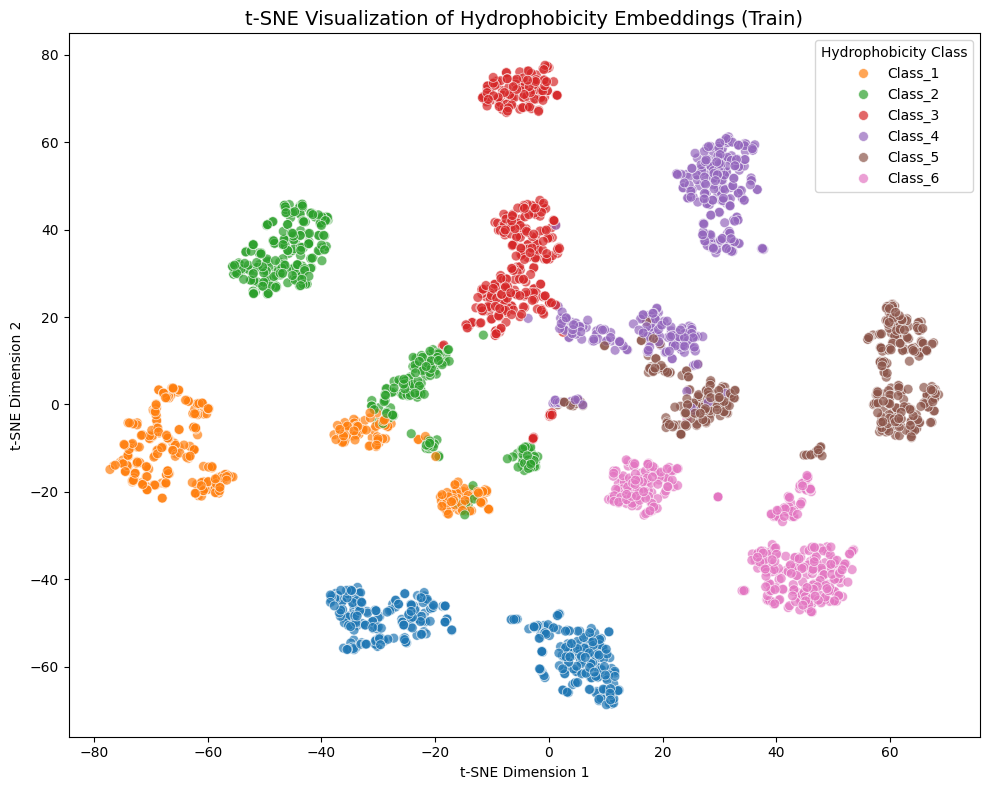

Unique labels in y_tr: [0 1 2 3 4 5 6]
Class counts: {0: 400, 1: 400, 2: 400, 3: 400, 4: 400, 5: 400, 6: 400}


In [19]:
# ===== 1. Imports =====
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ===== 2. Compute t-SNE (from your embedding space) =====
# Z_train: N × d feature matrix (e.g., X_train_pca or X_train embeddings)
# y_tr: length-N label vector (0..6)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)
Z_train_tsne = tsne.fit_transform(Z_train)   # shape: (N_samples, 2)
print("t-SNE shape:", Z_train_tsne.shape)

# ===== 3. Prepare class names Class_1 .. Class_7 =====
unique_classes = np.unique(y_tr)            # should be [0 1 2 3 4 5 6]
class_names = [f"Class_{int(c)+1}" for c in unique_classes]
print("Classes:", class_names)

# ===== 4. t-SNE scatter plot =====
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x=Z_train_tsne[:, 0],
    y=Z_train_tsne[:, 1],
    hue=y_tr,               # color by numeric labels
    palette="tab10",
    alpha=0.7,
    s=50
)

plt.title("t-SNE Visualization of Hydrophobicity Embeddings (Train)", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

# Fix legend: map 0..6 → Class_1..Class_7
handles, labels = scatter.get_legend_handles_labels()
# first label is usually "hue", skip it
plt.legend(handles=handles[1:], labels=class_names, title="Hydrophobicity Class")

plt.tight_layout()
plt.savefig("hydrophobicity_tsne_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Unique labels in y_tr:", np.unique(y_tr))
print("Class counts:", {int(c): (y_tr == c).sum() for c in np.unique(y_tr)})



Plot labels: [1 2 3 4 5 6 7]
Class names: ['Class_1', 'Class_2', 'Class_3', 'Class_4', 'Class_5', 'Class_6', 'Class_7']


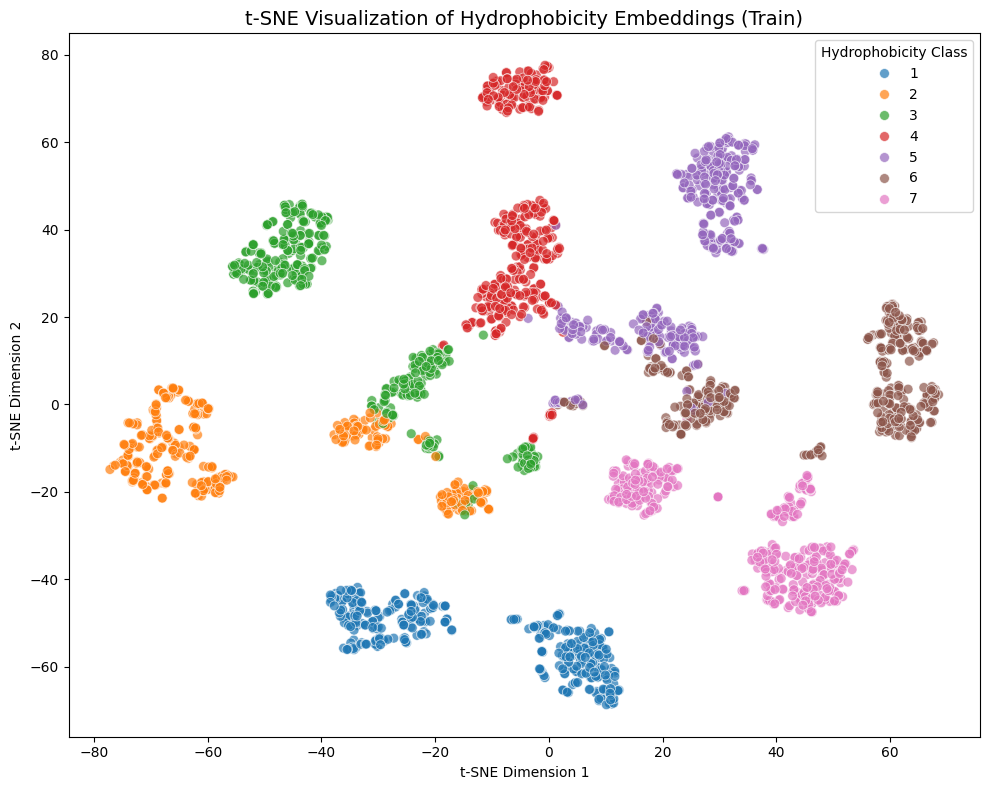

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your t-SNE is already computed: Z_train_tsne, y_tr

# Convert labels 0..6 → 1..7 for plotting only
y_tr_plot = y_tr + 1  # [0,1,2,3,4,5,6] → [1,2,3,4,5,6,7]
class_names = [f"Class_{i}" for i in range(1, 8)]  # Class_1 ... Class_7

print("Plot labels:", np.unique(y_tr_plot))
print("Class names:", class_names)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=Z_train_tsne[:, 0],
    y=Z_train_tsne[:, 1],
    hue=y_tr_plot,          # now hue=1..7 instead of 0..6
    palette="tab10",
    alpha=0.7,
    s=50
)

plt.title("t-SNE Visualization of Hydrophobicity Embeddings (Train)", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Hydrophobicity Class")  # Seaborn auto-labels hue=1..7 as Class_1..Class_7

plt.tight_layout()
plt.savefig("hydrophobicity_tsne_plot.png", dpi=300, bbox_inches="tight")
plt.show()
